In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    HuberRegressor
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


In [22]:
# Load California Housing dataset
housing = fetch_california_housing()

X = housing.data
y = housing.target

feature_names = housing.feature_names

print("Feature names:")
print(feature_names)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

df = pd.DataFrame(X, columns=feature_names)
df["Target"] = y

df.head()
df.info()
df.describe()

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Shape of X: (20640, 8)
Shape of y: (20640,)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [23]:
X_train, X_test, y_train, y_test = train_test_split (
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.mean(axis = 0))

[-6.59266865e-15 -6.68608149e-17  8.01559239e-15 -1.17273358e-15
 -2.60880895e-18 -1.13675656e-16  7.99652724e-14 -3.87910056e-13]


In [25]:
ols = LinearRegression()

ols.fit(X_train_scaled, y_train)

ols_pred = ols.predict(X_test_scaled)

In [26]:
ridge = Ridge(alpha = 1.0)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

In [27]:
lasso = Lasso(alpha = 0.01)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

In [28]:
huber = HuberRegressor()

huber.fit(X_train_scaled, y_train)

huber_pred = huber.predict(X_test_scaled)

In [29]:
def evaluate_model(name, y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

In [30]:
results = []

results.append(
    evaluate_model("OLS", y_test, ols_pred)
)

results.append(
    evaluate_model("Ridge", y_test, ridge_pred)
)

results.append(
    evaluate_model("LASSO", y_test, lasso_pred)
)

results.append(
    evaluate_model("Huber", y_test, huber_pred)
)

In [31]:
results_df = pd.DataFrame(results)

results_df

results_df.to_csv("metrics.csv", index = False)

In [32]:
#results_df.sort_values(by = "RMSE")
results_df.sort_values(by = "R2", ascending = False)

,Model,RMSE,MAE,R2
2,LASSO,0.740442,0.535326,0.581615
1,Ridge,0.745557,0.533193,0.575816
0,OLS,0.745581,0.533200,0.575788
3,Huber,0.758445,0.515846,0.561024


In [17]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "OLS": ols.coef_,
    "Ridge": ridge.coef_,
    "LASSO": lasso.coef_,
    "Huber": huber.coef_
})

coef_df

coef_df.to_csv("coef_df.csv", index = False)

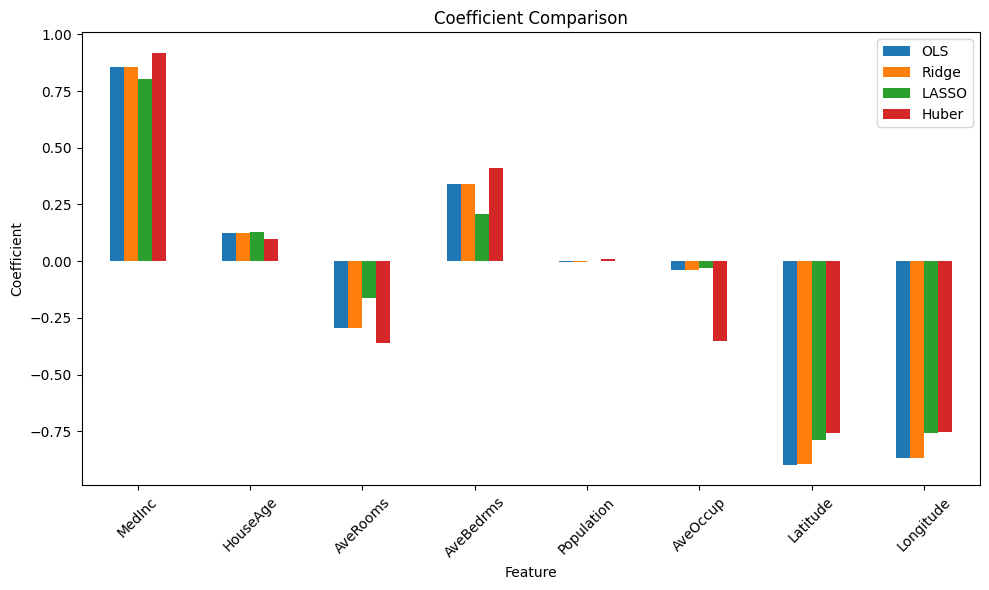

In [42]:
coef_plot = coef_df.set_index("Feature")

fig, ax = plt.subplots(figsize=(10, 6))

coef_plot.plot(kind="bar", ax=ax)

ax.set_title("Coefficient Comparison")
ax.set_ylabel("Coefficient")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig("../figures/coefficient_comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

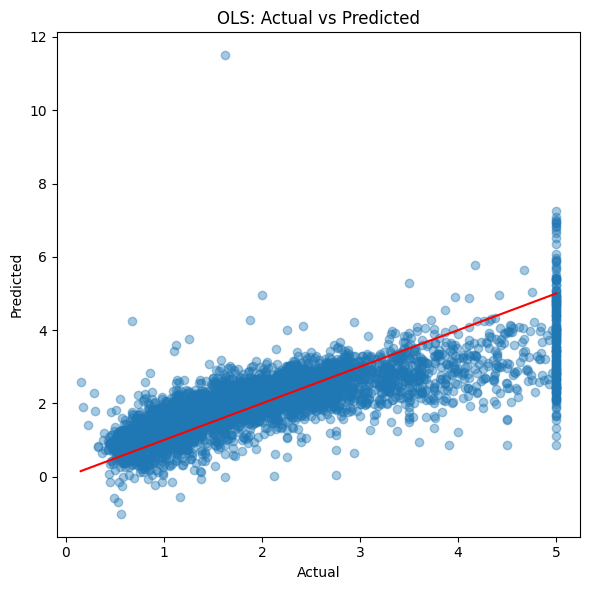

In [43]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_test, ols_pred, alpha=0.4)

ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title("OLS: Actual vs Predicted")

fig.tight_layout()

fig.savefig(
    "../figures/actual_vs_predicted_ols.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

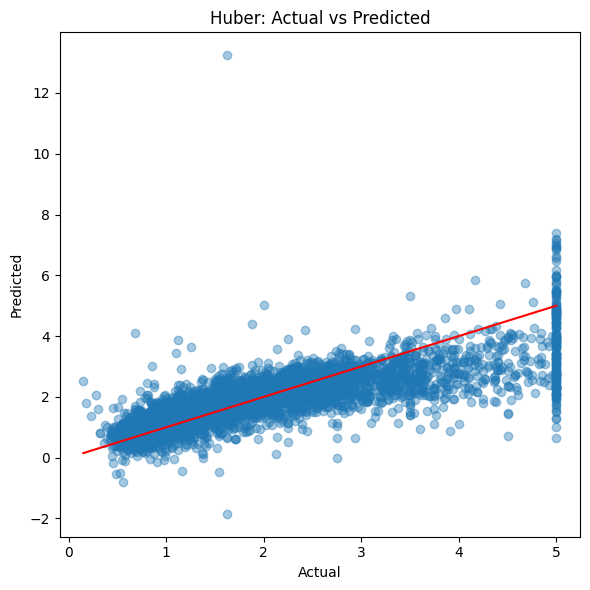

In [44]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_test, huber_pred, alpha=0.4)

ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title("Huber: Actual vs Predicted")

fig.tight_layout()

fig.savefig(
    "../figures/actual_vs_predicted_huber.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

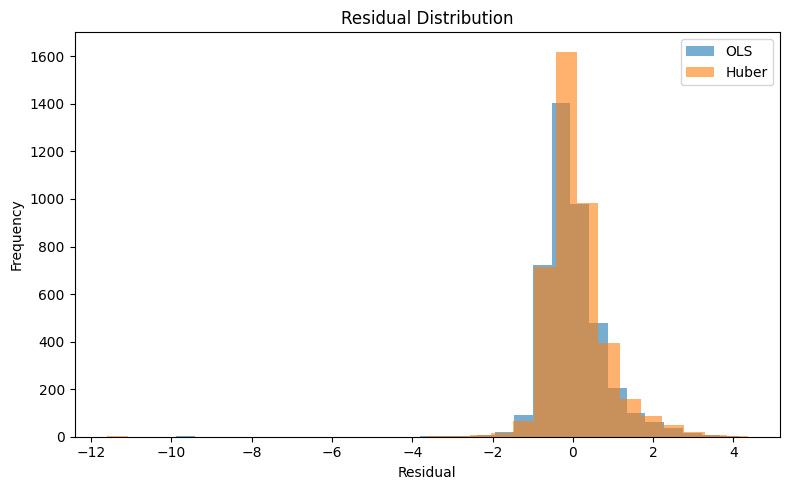

In [45]:
residual_ols = y_test - ols_pred
residual_huber = y_test - huber_pred

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(residual_ols, bins=30, alpha=0.6, label="OLS")
ax.hist(residual_huber, bins=30, alpha=0.6, label="Huber")

ax.legend()
ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
ax.set_title("Residual Distribution")

fig.tight_layout()

fig.savefig(
    "../figures/residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()